# 🎵 DL Model — EfficientNet-B0 + SpecAugment
**Dataset:** GTZAN Mel Spectrogram images  
**Model:** EfficientNet-B0 pretrained ImageNet → fine-tuned for music genre  
**Key upgrade:** SpecAugment (FrequencyMask + TimeMask) แก้ปัญหา rock/country recall ต่ำจาก baseline  
**Strategy:** Stage 1 freeze → Stage 2 unfreeze top blocks  

```
Mel PNG (224×224) → SpecAugment → EfficientNet-B0 → classifier head → 10 genres
```

### ทำไม SpecAugment ถึงช่วย?
- Mel Spectrogram คือภาพที่ **แกน Y = frequency**, **แกน X = time**
- **FrequencyMask**: ปิดแถบ frequency แบบสุ่ม → บังคับ model ไม่ให้พึ่ง frequency เดียว
- **TimeMask**: ปิดช่วง time แบบสุ่ม → ทำให้ robust กับเพลงที่มีช่วงเงียบ
- ผล: rock (F1=0.37 ใน baseline) ควรดีขึ้นเพราะ model เรียนจาก pattern ที่หลากหลายขึ้น

## 0. Colab Setup — Mount Drive & Install

In [1]:
# ── Mount Google Drive  ─────────────────
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sat Apr 11 03:28:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|          

In [2]:
DRIVE_BASE   = '/content/drive/MyDrive/test_music/'
MEL_PATH = '/content/drive/MyDrive/test_music/Data/mel_spectrograms'

In [3]:
!pip install torch torchvision torchaudio scikit-learn matplotlib seaborn tqdm -q
print('✅ Packages ready')

✅ Packages ready


## 1. Imports

In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries loaded')
print(f'   Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

✅ Libraries loaded
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB


## 2. Configuration

In [5]:
# ─── Paths ────────────────────────────────────────────────────────────
# MEL_PATH set in Cell 0 above
CHECKPOINT_PATH = 'best_efficientnet_specaug.pth'
ONNX_PATH       = 'efficientnet_genre_specaug.onnx'

# ─── Image ────────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32        # ลดเป็น 16 ถ้า Colab RAM ไม่พอ
NUM_CLASSES = 10

# ─── SpecAugment ──────────────────────────────────────────────────────
FREQ_MASK_PARAM = 20    # ปิดได้สูงสุด 20 pixel ในแกน frequency
TIME_MASK_PARAM = 30    # ปิดได้สูงสุด 30 pixel ในแกน time
N_FREQ_MASKS    = 2     # จำนวน frequency mask ต่อ image
N_TIME_MASKS    = 2     # จำนวน time mask ต่อ image

# ─── Training ─────────────────────────────────────────────────────────
STAGE1_EPOCHS = 5       # freeze backbone
STAGE1_LR     = 1e-3
STAGE2_EPOCHS = 20      # unfreeze top blocks (เพิ่มจาก 15 → 20 เพราะ SpecAugment ต้องการ epoch มากขึ้น)
STAGE2_LR     = 5e-5    # ลง lr นิดนึงเพราะ unfreeze มากขึ้น
WEIGHT_DECAY  = 1e-4

# ─── Split ────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1

GENRES = [
    'blues','classical','country','disco','hiphop',
    'jazz','metal','pop','reggae','rock'
]

# ImageNet normalization (required for pretrained EfficientNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print('✅ Config set')
print(f'   Stage 1 : {STAGE1_EPOCHS} epochs, lr={STAGE1_LR} (head only)')
print(f'   Stage 2 : {STAGE2_EPOCHS} epochs, lr={STAGE2_LR} (fine-tune)')
print(f'   SpecAug : FreqMask×{N_FREQ_MASKS}(max={FREQ_MASK_PARAM}px) + TimeMask×{N_TIME_MASKS}(max={TIME_MASK_PARAM}px)')

✅ Config set
   Stage 1 : 5 epochs, lr=0.001 (head only)
   Stage 2 : 20 epochs, lr=5e-05 (fine-tune)
   SpecAug : FreqMask×2(max=20px) + TimeMask×2(max=30px)


## 3. SpecAugment Custom Transform
Mask frequency bands และ time steps บน tensor Mel Spectrogram  
ทำหลัง `ToTensor()` เพราะ `torchaudio.transforms.FrequencyMasking` ทำงานกับ tensor

In [6]:
class SpecAugment(nn.Module):
    """
    SpecAugment สำหรับ Mel Spectrogram ที่บันทึกเป็น RGB image (3, H, W)

    - FrequencyMasking: ปิดแถบแนวนอน (pixel แกน H = frequency axis)
    - TimeMasking    : ปิดแถบแนวตั้ง (pixel แกน W = time axis)

    ใช้หลัง ToTensor() และ Normalize() — mask ด้วยค่า mean ของ ImageNet
    เพื่อให้ masked region ดู neutral แทนที่จะเป็น 0 (ดำ)
    """
    def __init__(
        self,
        freq_mask_param: int = 20,
        time_mask_param: int = 30,
        n_freq_masks:    int = 2,
        n_time_masks:    int = 2,
        fill_value:      float = 0.0   # หลัง normalize ค่า mean ≈ 0
    ):
        super().__init__()
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks    = n_freq_masks
        self.n_time_masks    = n_time_masks
        self.fill_value      = fill_value

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (C, H, W)  C=3, H=224 (freq), W=224 (time)
        _, H, W = x.shape
        x = x.clone()

        # FrequencyMasking — mask แนวนอน (H axis)
        for _ in range(self.n_freq_masks):
            f  = random.randint(0, self.freq_mask_param)
            f0 = random.randint(0, max(H - f, 0))
            x[:, f0:f0 + f, :] = self.fill_value

        # TimeMasking — mask แนวตั้ง (W axis)
        for _ in range(self.n_time_masks):
            t  = random.randint(0, self.time_mask_param)
            t0 = random.randint(0, max(W - t, 0))
            x[:, :, t0:t0 + t] = self.fill_value

        return x


print('✅ SpecAugment class defined')

# ── Quick sanity check ─────────────────────────────────────────────────
dummy = torch.rand(3, 224, 224)
aug   = SpecAugment(FREQ_MASK_PARAM, TIME_MASK_PARAM, N_FREQ_MASKS, N_TIME_MASKS)
out   = aug(dummy)
print(f'   Input shape : {dummy.shape}')
print(f'   Output shape: {out.shape}')
print(f'   Masked pixels: {(out == 0).sum().item()} / {out.numel()}')

✅ SpecAugment class defined
   Input shape : torch.Size([3, 224, 224])
   Output shape: torch.Size([3, 224, 224])
   Masked pixels: 22620 / 150528


## 4. Visualize SpecAugment Effect
ดูว่า augmentation ทำอะไรกับ Mel Spectrogram จริงๆ

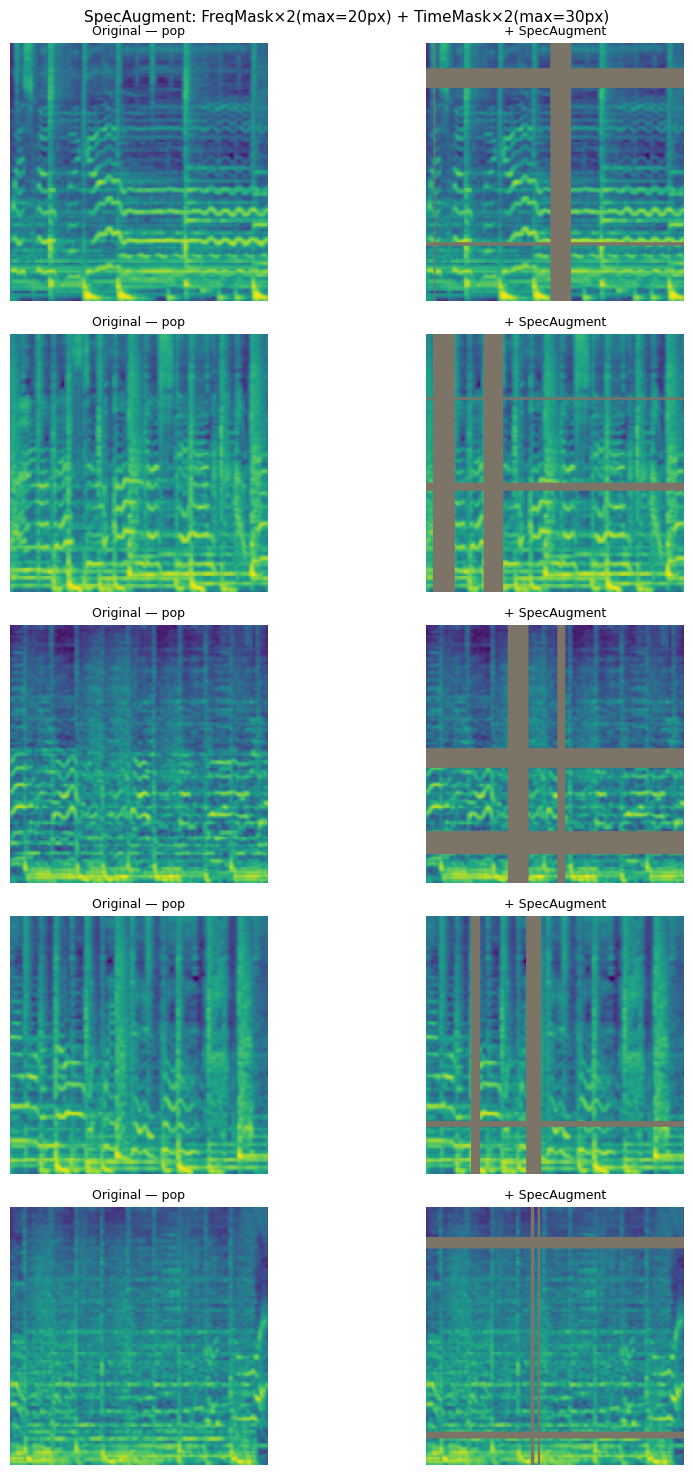

In [7]:
def show_specaugment_examples(mel_path, n_examples=5):
    """แสดง original vs augmented Mel Spectrogram เพื่อ verify SpecAugment"""
    # หา sample images
    sample_files = list(Path(mel_path).rglob('*.png'))[:n_examples]
    if not sample_files:
        print('⚠️  ไม่พบ PNG ใน', mel_path)
        return

    to_tensor = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    spec_aug = SpecAugment(FREQ_MASK_PARAM, TIME_MASK_PARAM, N_FREQ_MASKS, N_TIME_MASKS)

    def unnormalize(t):
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3*n_examples))
    for i, fpath in enumerate(sample_files):
        img = Image.open(fpath).convert('RGB')
        t   = to_tensor(img)
        t_aug = spec_aug(t.clone())

        genre = Path(fpath).parent.name
        axes[i, 0].imshow(unnormalize(t))
        axes[i, 0].set_title(f'Original — {genre}', fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(unnormalize(t_aug))
        axes[i, 1].set_title('+ SpecAugment', fontsize=9)
        axes[i, 1].axis('off')

    plt.suptitle(
        f'SpecAugment: FreqMask×{N_FREQ_MASKS}(max={FREQ_MASK_PARAM}px) + '
        f'TimeMask×{N_TIME_MASKS}(max={TIME_MASK_PARAM}px)',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('specaugment_examples.png', dpi=120, bbox_inches='tight')
    plt.show()


show_specaugment_examples(MEL_PATH)

## 5. DataLoader with SpecAugment

In [8]:
spec_augment = SpecAugment(
    freq_mask_param=FREQ_MASK_PARAM,
    time_mask_param=TIME_MASK_PARAM,
    n_freq_masks=N_FREQ_MASKS,
    n_time_masks=N_TIME_MASKS,
)

# Training: geometric aug → ToTensor → Normalize → SpecAugment
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),         # time flip (semantic sense สำหรับ mel)
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),  # slight shift
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    spec_augment,   # ← SpecAugment ทำบน tensor หลัง normalize
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # ไม่มี SpecAugment ตอน eval
])

# ── Load & Split ──────────────────────────────────────────────────────
full_ds = datasets.ImageFolder(MEL_PATH, transform=eval_transform)

n_total = len(full_ds)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Override train dataset ด้วย augmented transform
train_ds.dataset = datasets.ImageFolder(MEL_PATH, transform=train_transform)

# Colab: num_workers=2 ปกติพอ ถ้า error ให้ลองเป็น 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Dataset   : {n_total} samples total')
print(f'Split     : Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}')
print(f'Classes   : {full_ds.classes}')
print(f'Transforms: train has SpecAugment ✓ | val/test clean ✓')

Dataset   : 9981 samples total
Split     : Train 7984 | Val 998 | Test 999
Classes   : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Transforms: train has SpecAugment ✓ | val/test clean ✓


## 6. Build EfficientNet-B0

In [9]:
def build_efficientnet(num_classes=10, freeze_backbone=True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace head: 1280 → 512 → num_classes
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Total params    : {total:,}')
    print(f'  Trainable params: {trainable:,} ({100*trainable/total:.1f}%)')


model = build_efficientnet(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
print('✅ EfficientNet-B0 (backbone frozen)')
count_params(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 90.7MB/s]


✅ EfficientNet-B0 (backbone frozen)
  Total params    : 4,668,550
  Trainable params: 661,002 (14.2%)


## 7. Training Loop

In [10]:
def run_epoch(model, loader, criterion, optimizer=None, desc=''):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


def train_stage(model, train_loader, val_loader,
                epochs, lr, stage_name, history,
                label_smoothing=0.1):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/10)

    best_val_acc = 0.0
    print(f'\n{"="*60}')
    print(f'  {stage_name}')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        saved = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            saved = ' ✅'

        print(f'  Ep {epoch:3d}/{epochs} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'Acc  {tr_acc:.4f}/{vl_acc:.4f}{saved}')

    return best_val_acc


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print('✅ Training utilities ready')

✅ Training utilities ready


## 8. Stage 1 — Train Head Only (backbone frozen)
ให้ classifier head เรียน feature ก่อน ~5 epoch เร็วมาก

In [11]:
best_s1 = train_stage(
    model, train_loader, val_loader,
    epochs=STAGE1_EPOCHS,
    lr=STAGE1_LR,
    stage_name=f'Stage 1 — Head only (backbone frozen) | lr={STAGE1_LR}',
    history=history
)
print(f'\n🏆 Stage 1 best val acc: {best_s1:.4f}')


  Stage 1 — Head only (backbone frozen) | lr=0.001
  Ep   1/5 | Loss 1.7987/1.5086 | Acc  0.4092/0.5691 ✅
  Ep   2/5 | Loss 1.6351/1.4329 | Acc  0.4922/0.5782 ✅
  Ep   3/5 | Loss 1.5839/1.4019 | Acc  0.5185/0.5882 ✅
  Ep   4/5 | Loss 1.5514/1.3431 | Acc  0.5313/0.6343 ✅
  Ep   5/5 | Loss 1.5444/1.3370 | Acc  0.5420/0.6343

🏆 Stage 1 best val acc: 0.6343


## 9. Stage 2 — Unfreeze Top Blocks + Fine-tune
Unfreeze features[5], features[6], features[7] (top MBConv blocks + head conv)

In [12]:
UNFREEZE_FROM = 5  # features[5..7]

for i, layer in enumerate(model.features):
    if i >= UNFREEZE_FROM:
        for param in layer.parameters():
            param.requires_grad = True

print('Unfrozen layers:')
for i, layer in enumerate(model.features):
    trainable = any(p.requires_grad for p in layer.parameters())
    status    = '🔓 trainable' if trainable else '🔒 frozen'
    print(f'  features[{i}] {layer.__class__.__name__:<30} {status}')

print()
count_params(model)

Unfrozen layers:
  features[0] Conv2dNormActivation           🔒 frozen
  features[1] Sequential                     🔒 frozen
  features[2] Sequential                     🔒 frozen
  features[3] Sequential                     🔒 frozen
  features[4] Sequential                     🔒 frozen
  features[5] Sequential                     🔓 trainable
  features[6] Sequential                     🔓 trainable
  features[7] Sequential                     🔓 trainable
  features[8] Conv2dNormActivation           🔓 trainable

  Total params    : 4,668,550
  Trainable params: 4,359,890 (93.4%)


In [13]:
best_s2 = train_stage(
    model, train_loader, val_loader,
    epochs=STAGE2_EPOCHS,
    lr=STAGE2_LR,
    stage_name=f'Stage 2 — Fine-tune top blocks | lr={STAGE2_LR}',
    history=history
)
print(f'\n🏆 Stage 2 best val acc: {best_s2:.4f}')


  Stage 2 — Fine-tune top blocks | lr=5e-05
  Ep   1/20 | Loss 1.4408/1.1666 | Acc  0.5916/0.7114 ✅
  Ep   2/20 | Loss 1.2977/1.0810 | Acc  0.6577/0.7625 ✅
  Ep   3/20 | Loss 1.2284/1.0217 | Acc  0.6861/0.7916 ✅
  Ep   4/20 | Loss 1.1801/0.9792 | Acc  0.7196/0.8156 ✅
  Ep   5/20 | Loss 1.1255/0.9505 | Acc  0.7430/0.8246 ✅
  Ep   6/20 | Loss 1.0970/0.9351 | Acc  0.7576/0.8257 ✅
  Ep   7/20 | Loss 1.0680/0.9113 | Acc  0.7692/0.8327 ✅
  Ep   8/20 | Loss 1.0387/0.8835 | Acc  0.7791/0.8477 ✅
  Ep   9/20 | Loss 1.0179/0.8642 | Acc  0.7938/0.8527 ✅
  Ep  10/20 | Loss 0.9920/0.8519 | Acc  0.8021/0.8627 ✅
  Ep  11/20 | Loss 0.9816/0.8372 | Acc  0.8161/0.8677 ✅
  Ep  12/20 | Loss 0.9576/0.8255 | Acc  0.8161/0.8737 ✅
  Ep  13/20 | Loss 0.9510/0.8230 | Acc  0.8195/0.8798 ✅
  Ep  14/20 | Loss 0.9451/0.8120 | Acc  0.8211/0.8758
  Ep  15/20 | Loss 0.9334/0.8060 | Acc  0.8250/0.8798
  Ep  16/20 | Loss 0.9280/0.8031 | Acc  0.8335/0.8888 ✅
  Ep  17/20 | Loss 0.9147/0.7984 | Acc  0.8409/0.8888
  Ep  18/

## 10. Training Curves

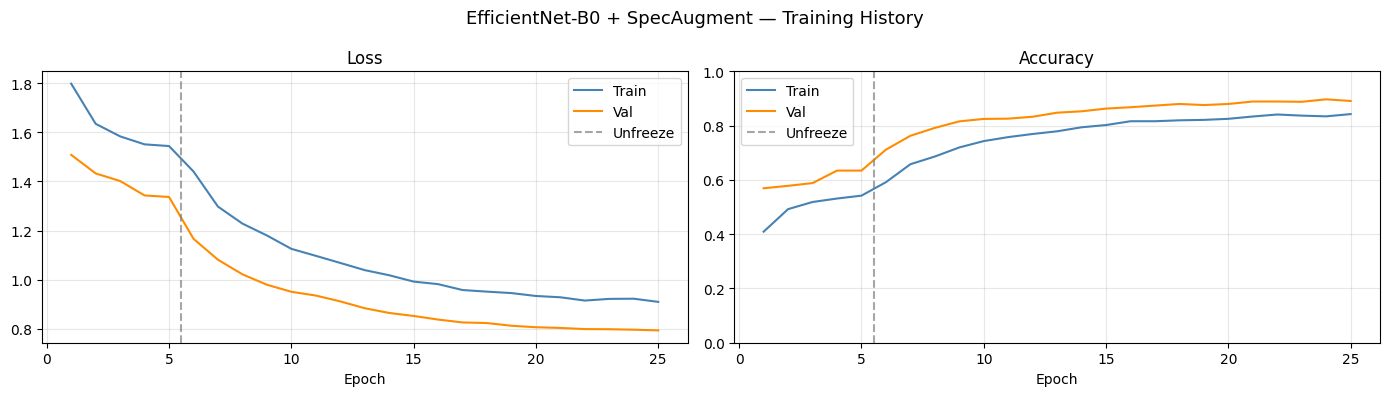

Best val acc — Stage1: 0.6343 | Stage2: 0.8968


In [14]:
total_epochs = STAGE1_EPOCHS + STAGE2_EPOCHS
ep = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (tr_key, vl_key), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss', 'Accuracy']
):
    ax.plot(ep, history[tr_key], label='Train', color='steelblue')
    ax.plot(ep, history[vl_key], label='Val',   color='darkorange')
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle='--',
               alpha=0.7, label='Unfreeze')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if title == 'Accuracy':
        ax.set_ylim(0, 1)

plt.suptitle('EfficientNet-B0 + SpecAugment — Training History', fontsize=13)
plt.tight_layout()
plt.savefig('efficientnet_specaug_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val acc — Stage1: {best_s1:.4f} | Stage2: {best_s2:.4f}')

## 11. Evaluate on Test Set

In [15]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = logits.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='macro')

print('=' * 55)
print('  EfficientNet-B0 + SpecAugment — Test Results')
print('=' * 55)
print(f'  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 Macro : {f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=GENRES))

  EfficientNet-B0 + SpecAugment — Test Results
  Accuracy : 0.8869 (88.69%)
  F1 Macro : 0.8835

              precision    recall  f1-score   support

       blues       0.96      0.94      0.95        95
   classical       0.95      0.99      0.97       124
     country       0.82      0.84      0.83        87
       disco       0.84      0.86      0.85        81
      hiphop       0.90      0.88      0.89        92
        jazz       0.94      0.93      0.93       108
       metal       0.93      0.94      0.94       104
         pop       0.84      0.94      0.89       101
      reggae       0.92      0.89      0.90        99
        rock       0.73      0.64      0.68       108

    accuracy                           0.89       999
   macro avg       0.88      0.88      0.88       999
weighted avg       0.89      0.89      0.89       999



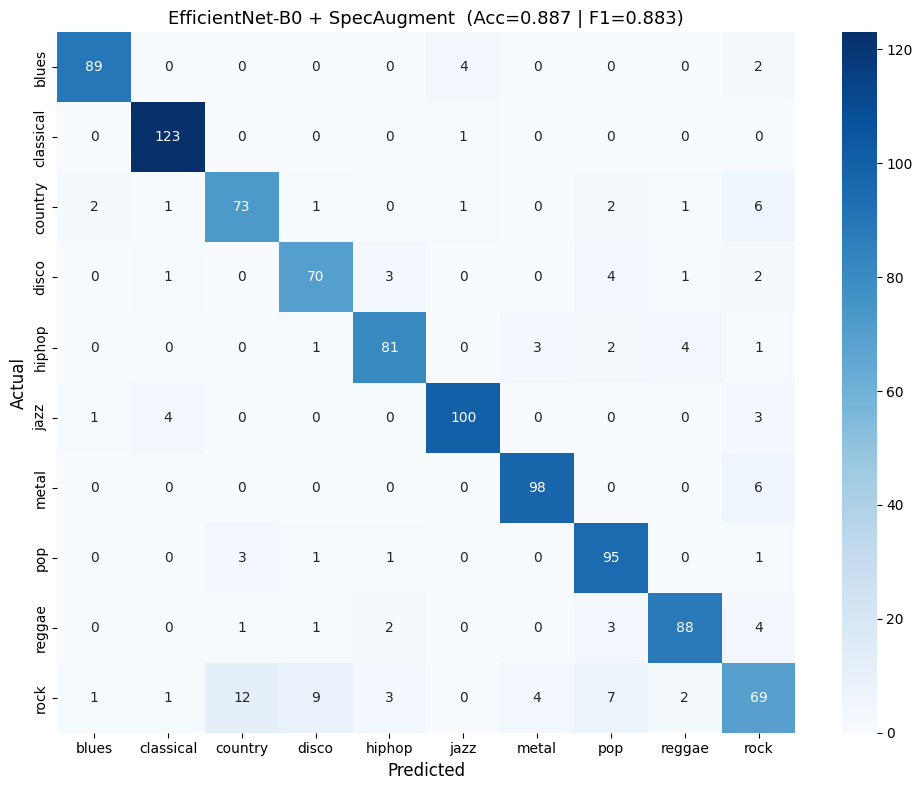

In [16]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(
    f'EfficientNet-B0 + SpecAugment  (Acc={acc:.3f} | F1={f1:.3f})',
    fontsize=13
)
plt.tight_layout()
plt.savefig('efficientnet_specaug_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Compare vs Baseline (side-by-side)
เทียบกับ baseline CNN (Acc=74.3%, F1=0.727) โดยตรง

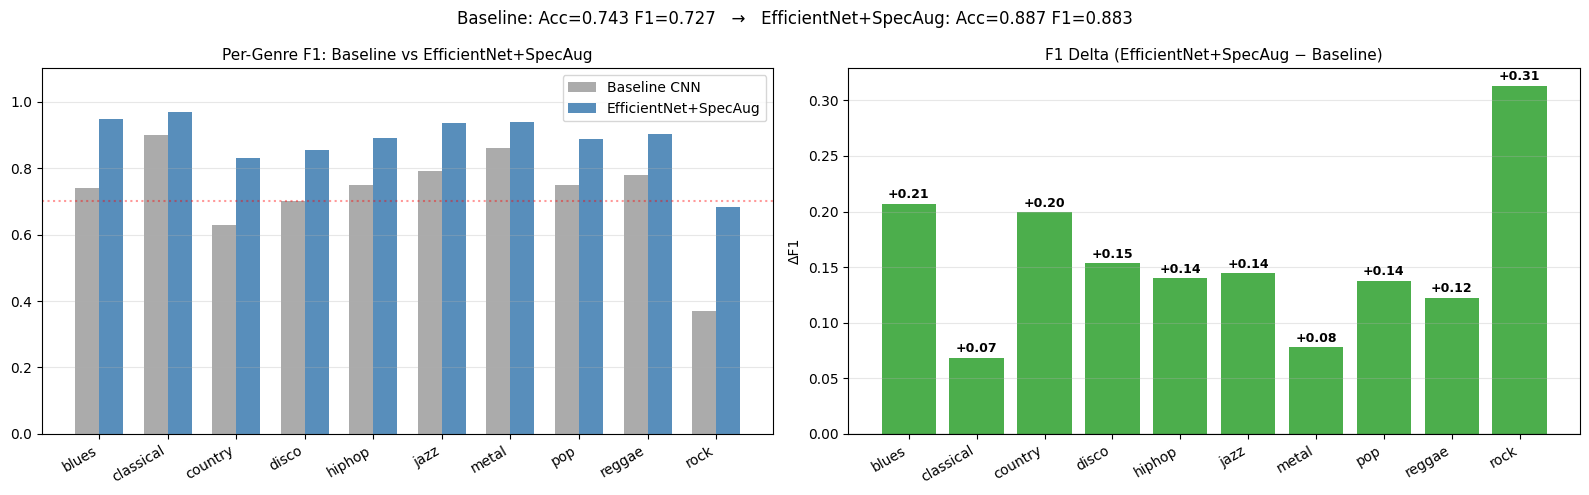


=== Comparison Table ===
    Genre Baseline F1 New F1  Delta
    blues       0.740  0.947 +0.207
classical       0.900  0.969 +0.069
  country       0.630  0.830 +0.200
    disco       0.700  0.854 +0.154
   hiphop       0.750  0.890 +0.140
     jazz       0.790  0.935 +0.145
    metal       0.860  0.938 +0.078
      pop       0.750  0.888 +0.138
   reggae       0.780  0.903 +0.123
     rock       0.370  0.683 +0.313

Overall  Baseline: Acc=0.7427 F1=0.7270
         New     : Acc=0.8869          F1=0.8835
         Delta   : Acc=+0.1442     F1=+0.1565


In [17]:
# ── Baseline numbers จาก baseline_model.ipynb ────────────────────────
BASELINE_ACC = 0.7427
BASELINE_F1  = 0.7270
BASELINE_PER_GENRE_F1 = {
    'blues': 0.74, 'classical': 0.90, 'country': 0.63, 'disco': 0.70,
    'hiphop': 0.75, 'jazz': 0.79, 'metal': 0.86, 'pop': 0.75,
    'reggae': 0.78, 'rock': 0.37
}

# ── Per-genre F1 ของ model ปัจจุบัน ──────────────────────────────────
from sklearn.metrics import f1_score as f1_per
new_per_genre = {}
for i, g in enumerate(GENRES):
    mask = all_labels == i
    if mask.sum() > 0:
        new_per_genre[g] = f1_score(
            all_labels[mask] == i,
            all_preds[mask]  == i,
            zero_division=0
        )

# ── Report from sklearn (more accurate) ──────────────────────────────
report = classification_report(
    all_labels, all_preds, target_names=GENRES, output_dict=True
)
new_per_genre_f1 = {g: report[g]['f1-score'] for g in GENRES}

# ── Plot ─────────────────────────────────────────────────────────────
x      = np.arange(len(GENRES))
width  = 0.35
base_f = [BASELINE_PER_GENRE_F1[g] for g in GENRES]
new_f  = [new_per_genre_f1[g]      for g in GENRES]
deltas = [n - b for n, b in zip(new_f, base_f)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: per-genre F1 comparison
ax = axes[0]
bars1 = ax.bar(x - width/2, base_f, width, label='Baseline CNN', color='#888', alpha=0.7)
bars2 = ax.bar(x + width/2, new_f,  width, label='EfficientNet+SpecAug', color='steelblue', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(GENRES, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Per-Genre F1: Baseline vs EfficientNet+SpecAug', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.7, color='red', linestyle=':', alpha=0.4)

# Right: delta (improvement)
ax2 = axes[1]
colors = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
ax2.bar(GENRES, deltas, color=colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticklabels(GENRES, rotation=30, ha='right', fontsize=10)
ax2.set_title('F1 Delta (EfficientNet+SpecAug − Baseline)', fontsize=11)
ax2.set_ylabel('ΔF1')
ax2.grid(axis='y', alpha=0.3)
for i, (g, d) in enumerate(zip(GENRES, deltas)):
    ax2.text(i, d + (0.005 if d >= 0 else -0.015), f'{d:+.2f}',
             ha='center', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Baseline: Acc={BASELINE_ACC:.3f} F1={BASELINE_F1:.3f}   →   '
    f'EfficientNet+SpecAug: Acc={acc:.3f} F1={f1:.3f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('comparison_baseline_vs_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print('\n=== Comparison Table ===')
summary = pd.DataFrame({
    'Genre'       : GENRES,
    'Baseline F1' : [f'{BASELINE_PER_GENRE_F1[g]:.3f}' for g in GENRES],
    'New F1'      : [f'{new_per_genre_f1[g]:.3f}'       for g in GENRES],
    'Delta'       : [f'{new_per_genre_f1[g]-BASELINE_PER_GENRE_F1[g]:+.3f}' for g in GENRES],
})
print(summary.to_string(index=False))
print(f'\nOverall  Baseline: Acc={BASELINE_ACC:.4f} F1={BASELINE_F1:.4f}')
print(f'         New     : Acc={acc:.4f}          F1={f1:.4f}')
print(f'         Delta   : Acc={acc-BASELINE_ACC:+.4f}     F1={f1-BASELINE_F1:+.4f}')

## 13. Export to ONNX (สำหรับ Part 5 Real-time Pipeline)

In [18]:
model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=['mel_image'],
    output_names=['genre_logits'],
    dynamic_axes={
        'mel_image':    {0: 'batch_size'},
        'genre_logits': {0: 'batch_size'}
    },
    opset_version=17
)

size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f'✅ ONNX exported → {ONNX_PATH} ({size_mb:.1f} MB)')
print(f'   Input  : (batch, 3, 224, 224)  — normalized Mel image')
print(f'   Output : (batch, {NUM_CLASSES})  — raw logits → apply softmax')
print(f'   Note   : SpecAugment ไม่อยู่ใน ONNX (training only)')
print(f'   Next   : Part 5 Sliding Window pipeline ใช้ ONNX นี้ได้เลย')

ModuleNotFoundError: No module named 'onnxscript'

## 14. Save to Google Drive

In [ ]:
# ── Copy outputs ไปยัง Drive ──────────────────────────────────────────
# SAVE_DIR = '/content/drive/MyDrive/GTZAN/outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

import shutil
files_to_save = [
    CHECKPOINT_PATH,
    ONNX_PATH,
    'efficientnet_specaug_curves.png',
    'efficientnet_specaug_confusion.png',
    'comparison_baseline_vs_efficientnet.png',
    'specaugment_examples.png',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f'  ✅ {f} → {SAVE_DIR}')
    else:
        print(f'  ⚠️  {f} not found (skip)')

print(f'\nAll outputs saved to {SAVE_DIR}')

---
## Summary

| Item | Detail |
|---|---|
| **Model** | EfficientNet-B0 (pretrained ImageNet) |
| **Key upgrade** | SpecAugment: FreqMask×2 + TimeMask×2 |
| **Normalization** | ImageNet mean/std (แก้จาก baseline ที่ใช้ [0.5,0.5,0.5]) |
| **Training** | Stage 1: head only (5 ep, lr=1e-3) → Stage 2: unfreeze top blocks (20 ep, lr=5e-5) |
| **Loss** | CrossEntropy + label smoothing 0.1 |
| **Checkpoint** | `best_efficientnet_specaug.pth` |
| **ONNX** | `efficientnet_genre_specaug.onnx` (พร้อม Part 5) |
| **Target** | rock F1: 0.37 → 0.65+ · Overall F1: 0.727 → 0.82+ |
| **Next** | Part 5 — Real-time Sliding Window Pipeline |